---
title: Reproducing the solar cloud radiative effect with libRadtran
label: libradtran-cre-example
---
# libRadtran &mdash; the solar cloud radiative effect over Arctic sea ice

Author of this notebook:
 - *Joshua Müller*, [Leipzig Institute for Meteorology](https://www.physgeo.uni-leipzig.de/institut-fuer-meteorologie), Leipzig University, Germany, *email*

This notebook is licensed under the [Creative Commons Attribution 4.0 International](http://creativecommons.org/licenses/by/4.0/ "CC-BY-4.0")

## Dataset description

**Title:** Aircraft measurements of broadband irradiance during the ACLOUD campaign in 2017

**Authors:** Stapf, Johannes; Ehrlich, André; Jäkel, Evelyn; Wendisch, Manfred

**Description:** Solar and terrestrial broadband irradiance and nadir brightness temperature measured by upward- and downward-looking pyranometers and pyrgeometers aboard the *Polar 5* aircraft during the ACLOUD campaign [@wendisch2019] north-west of Svalbard in May/June 2017. One netCDF file is provided per research flight.

**Year:** 2019

**Institute:** Leipzig University

**DOI:** [10.1594/PANGAEA.900442](https://doi.org/10.1594/PANGAEA.900442) [@stapf2019data]

**License:** [Creative Commons Attribution 4.0 International](http://creativecommons.org/licenses/by/4.0/)

## Contents of this notebook

This notebook is a compact showcase of [`pyRadtran`](https://github.com/FranzFlink/pyRadtran), a thin `xarray` wrapper around the radiative transfer library **libRadtran**. It reproduces the key idea behind Fig. 7 of @becker2023: the **solar cloud radiative effect** (CRE$_\mathrm{sol}$) as a function of the underlying **surface albedo** for the ACLOUD campaign. To do so we

1. download the airborne broadband irradiance observations from PANGAEA,
2. run a **clear-sky** libRadtran simulation along the flight track with `pyRadtran`, and
3. combine measurement and simulation to obtain CRE$_\mathrm{sol}$ and visualise it as a two-dimensional probability density.


## A short introduction to libRadtran and pyRadtran

**libRadtran** is a widely used, freely available *library for radiative transfer* calculations [@mayer2005; @emde2016]. Its main tool, `uvspec`, solves the radiative transfer equation through a user-defined atmosphere and returns spectral or broadband irradiances and radiances. The radiative transfer equation is solved by one of several solvers; the default for irradiances is **DISORT**, the discrete-ordinate method of @stamnes1988. A simulation is configured through a plain-text input file that specifies, e.g., the `source` (solar or thermal), the atmospheric profile, trace-gas amounts, the surface `albedo`, the solar zenith angle and the wavelength range.

The **cloud radiative effect** (CRE) is the difference between the net irradiance of the *real* (cloudy) atmosphere and that of an otherwise identical *cloud-free* atmosphere. The cloudy term is measured by the aircraft; the cloud-free reference cannot be observed and is instead **simulated with libRadtran** &mdash; exactly the approach taken by @becker2023.

[`pyRadtran`](https://github.com/FranzFlink/pyRadtran) makes this workflow accessible from Python: it registers a `.pyradtran` accessor on `xarray.Dataset` objects, builds the `uvspec` input files for every point of a space–time grid, runs them (optionally in parallel) and returns the results as an `xarray.Dataset`.

```{note}
Running the simulation cells below requires a working **libRadtran** installation and the `pyradtran` package. libRadtran does not run inside the browser-based book build, so the simulation cells are shipped without stored output &mdash; execute them on a machine where `uvspec` is available.
```


## Import relevant modules

Besides the usual scientific stack (`numpy`, `xarray`, `matplotlib`) we use [`pangaeapy`](https://pypi.org/project/pangaeapy/) to query the PANGAEA data publication and `pyradtran` for the radiative transfer simulation.

In [1]:
import urllib.request
from pathlib import Path

import numpy as np
import xarray as xr
import matplotlib.pyplot as plt


import pangaeapy as pgp   # query PANGAEA datasets
import pyradtran          # registers the .pyradtran xarray accessor

import logging
logging.getLogger('pyradtran').setLevel(logging.INFO)

## Download the broadband irradiance data from PANGAEA

The parent dataset [10.1594/PANGAEA.900442](https://doi.org/10.1594/PANGAEA.900442) is a *collection* of netCDF files, one per research flight. We download all of them, to be able to reproduce a figure from []

In [2]:
# List the files contained in the PANGAEA collection
cat = pgp.PanDataSet(900442, enable_cache=True)

import nest_asyncio
nest_asyncio.apply()
filenames = cat.download(indices=list(np.arange(len(cat.data)-1)), columns=["URL file"])
print(filenames)

File ACLOUD_20170523_Airborne_Broadband_Irradiance.nc already exists, skipping.
File ACLOUD_20170531_Airborne_Broadband_Irradiance.nc already exists, skipping.
File ACLOUD_20170525_Airborne_Broadband_Irradiance.nc already exists, skipping.
File ACLOUD_20170604_Airborne_Broadband_Irradiance.nc already exists, skipping.
File ACLOUD_20170605_Airborne_Broadband_Irradiance.nc already exists, skipping.
File ACLOUD_20170529_Airborne_Broadband_Irradiance.nc already exists, skipping.
File ACLOUD_20170530_Airborne_Broadband_Irradiance.nc already exists, skipping.
File ACLOUD_20170527_Airborne_Broadband_Irradiance.nc already exists, skipping.
File ACLOUD_20170602_Airborne_Broadband_Irradiance.nc already exists, skipping.
File ACLOUD_20170614_Airborne_Broadband_Irradiance.nc already exists, skipping.
File ACLOUD_20170608_Airborne_Broadband_Irradiance.nc already exists, skipping.
File ACLOUD_20170617_Airborne_Broadband_Irradiance.nc already exists, skipping.
File ACLOUD_20170609_Airborne_Broadband_

In [3]:
import netCDF4
nc = netCDF4.Dataset(filenames[-3])
print("Groups:", list(nc.groups.keys()))
print("Root variables:", list(nc.variables.keys()))

Groups: ['P5', 'P6']
Root variables: []


In [4]:
list_of_datasets = []

for f in filenames:

    try: 
        ds = xr.open_dataset(f, engine="netcdf4", group="P6").coarsen(Time=200, boundary="trim").mean() #resample to 0.1Hz (20Hz original data)
        low_altitude_filter = ds["Alt"] < 100
        list_of_datasets.append(ds.isel(Time=low_altitude_filter).swap_dims({"Time": "time"}))
    except Exception as e:
        print(f"Error opening {f}: {e}")
        continue

obs = xr.concat(list_of_datasets, dim="time").sortby("time")

Error opening /home/josh/.pangaeapy_cache/ACLOUD_20170523_Airborne_Broadband_Irradiance.nc: [Errno -51] NetCDF: Unknown file format: '/home/josh/.pangaeapy_cache/ACLOUD_20170523_Airborne_Broadband_Irradiance.nc'
Error opening /home/josh/.pangaeapy_cache/ACLOUD_20170525_Airborne_Broadband_Irradiance.nc: [Errno -51] NetCDF: Unknown file format: '/home/josh/.pangaeapy_cache/ACLOUD_20170525_Airborne_Broadband_Irradiance.nc'
Error opening /home/josh/.pangaeapy_cache/ACLOUD_20170527_Airborne_Broadband_Irradiance.nc: [Errno -51] NetCDF: Unknown file format: '/home/josh/.pangaeapy_cache/ACLOUD_20170527_Airborne_Broadband_Irradiance.nc'


## Pre-process the observations

From the up- and downward broadband solar irradiances we obtain the **measured net solar irradiance** and the **surface albedo**.

In [5]:
# ---- adjust the variable names to match the dataset printed above ----
F_dw = obs["Solar_F_dw"]    # measured downward broadband solar irradiance (W m-2)
F_up = obs["Solar_F_up"]      # measured upward   broadband solar irradiance (W m-2)

# measured broadband surface albedo and net (downward-positive) solar irradiance
albedo = (F_up / F_dw).clip(0.0, 1.0)
F_net_meas = F_dw - F_up

## Clear-sky simulation with pyRadtran

We build an `xarray.Dataset` carrying the flight track (`time`, `latitude`, `longitude`) and hand it to the `.pyradtran` accessor. The configuration file [`config/clearsky_solar.yaml`](./config/clearsky_solar.yaml) selects a **clear-sky, broadband solar** simulation (TWOSTR solver, 300–3600 nm, subarctic-summer atmosphere); the solar zenith angle is computed automatically from time and position.

In [6]:

track = xr.Dataset(
    coords={
        "time": obs["time"],
        "latitude": ("time", np.asarray(obs["Lat"])),
        "longitude": ("time", np.asarray(obs["Lon"])),
    }
).isel(time=slice(0, -1))

# Run libRadtran along the track (requires uvspec + pyradtran)
# logging.getLogger('pyradtran').setLevel(logging.DEBUG) this shows the full uvspec command line and output, which is useful for debugging

# runs ~111 simulations (one for each time step) and saves the results to a netCDF file (took ~25 seconds on a laptop with 4 cores)
sim = track.pyradtran.run(
    config_path=Path("config/clearsky_solar.yaml"),
    return_dataset=True,
    save_to_file=True,
    show_progress=True,
)

# clear-sky global (direct + diffuse) downward solar irradiance at flight level

2026-06-30 11:50:16,732 - pyradtran.interface - INFO - Auto-generating output path: pyradtran_output/acloud_clearsky_20260630_115016_results.nc
2026-06-30 11:50:16,738 - pyradtran.interface - INFO - Preparing 3056 simulations from input dataset with dims ['time']
/home/josh/pyRadtran/pyradtran/interface.py:419: UserWarning: Discarding nonzero nanoseconds in conversion.
  dt = pd.to_datetime(t).to_pydatetime()
Running simulations: 100%|██████████| 3056/3056 [10:50<00:00,  4.70sim/s, Success=3056, Total=3056]
2026-06-30 12:01:10,795 - pyradtran.interface - INFO - Batch execution completed: 3056/3056 simulations successful
2026-06-30 12:01:29,071 - pyradtran.io - INFO - Results saved to pyradtran_output/acloud_clearsky_20260630_115016_results.nc
2026-06-30 12:01:29,072 - pyradtran.interface - INFO - Results saved to pyradtran_output/acloud_clearsky_20260630_115016_results.nc


<xarray.DataArray 'eglo' (time: 3056)> Size: 24kB
array([345371.55666315, 358047.98674917, 358226.36064151, ...,
       411856.2738335 , 411856.2738335 , 411681.13833458], shape=(3056,))
Coordinates:
  * time      (time) datetime64[ns] 24kB 2017-05-29T05:11:45.025000 ... 2017-...
    altitude  int64 8B 0

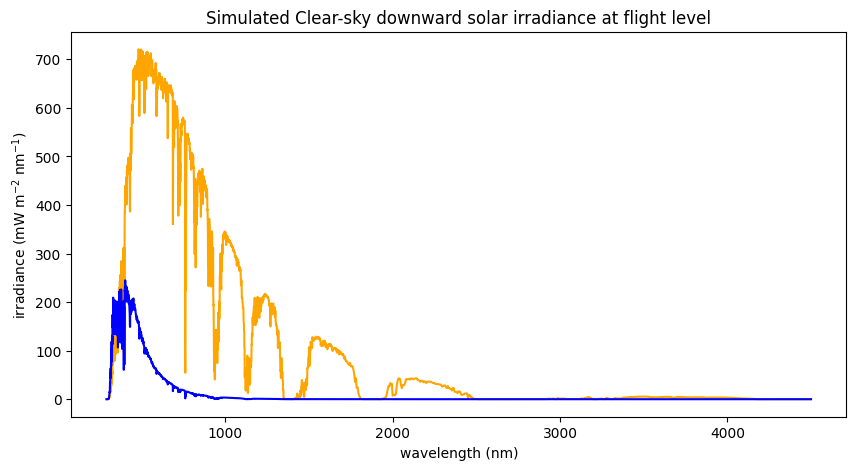

In [12]:
fig, ax = plt.subplots(figsize=(10, 5))
sim['edir'].mean(dim='time').plot(label="direct", color="orange")
sim['edn'].mean(dim='time').plot(label="diffuse", color="blue")

ax.set_xlabel("wavelength (nm)")
ax.set_ylabel("irradiance (mW m$^{-2}$ nm$^{-1}$)")
ax.set_title("Simulated Clear-sky downward solar irradiance at flight level")

sim_broadband = sim.integrate('wavelength')
F_dw_clear = sim_broadband["eglo"].squeeze()
F_dw_clear

## The solar cloud radiative effect

Following @becker2023, the solar cloud radiative effect is the difference between the measured and the simulated clear-sky **net** solar irradiance,

$$\mathrm{CRE_{sol}} = \left(F^{\downarrow} - F^{\uparrow}\right)_\mathrm{meas} - \left(F^{\downarrow} - F^{\uparrow}\right)_\mathrm{clear}.$$

The clear-sky downward irradiance is almost independent of the surface albedo, whereas the clear-sky *upward* irradiance scales with it. We therefore reconstruct the clear-sky net flux from the measured albedo as $F_\mathrm{net,clear} = (1-\alpha)\,F^{\downarrow}_\mathrm{clear}$, after interpolating the simulation back onto the full measurement grid.

In [13]:
# interpolate the (sub-sampled) clear-sky simulation onto the measurement grid
F_dw_clear_full = F_dw_clear.interp(time=obs["time"]) / 1000

# clear-sky net solar irradiance and the solar cloud radiative effect
F_net_clear = (1.0 - albedo) * F_dw_clear_full
cre_sol = F_net_meas - F_net_clear

## Reproducing Fig. 7: CRE$_\mathrm{sol}$ versus surface albedo

Finally we visualise the relationship between the solar cloud radiative effect and the surface albedo as a two-dimensional probability density &mdash; the core panel of Fig. 7 in @becker2023. The cloud-free ocean, cloud-free ice and cloudy regimes appear as distinct modes; cooling (negative CRE$_\mathrm{sol}$) dominates over the dark ocean while the effect weakens over the bright sea ice.

Text(0.5, 1.0, 'ACLOUD — solar cloud radiative effect vs. surface albedo')

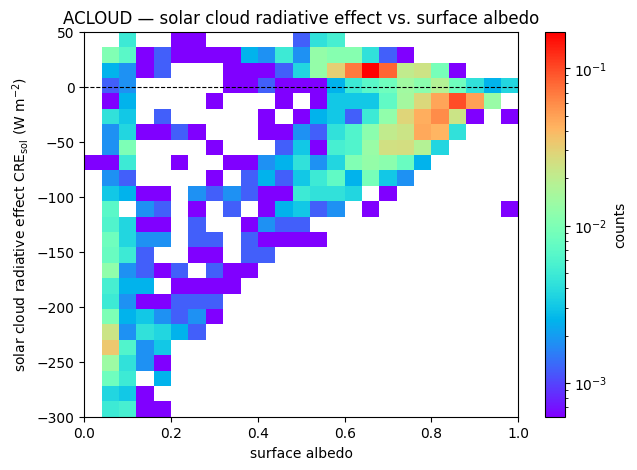

In [ ]:
a = np.asarray(albedo).ravel()
c = np.asarray(cre_sol).ravel()
m = np.isfinite(a) & np.isfinite(c)

fig, ax = plt.subplots(figsize=(7, 5))

h = ax.hist2d(
    a[m],
    c[m],
    bins=25,
    range=[[0, 1], [-300, 50]],
    cmap="rainbow",
    norm=plt.matplotlib.colors.LogNorm(),
    density=True
)
plt.colorbar(h[3], label="counts")

ax.axhline(0.0, color="k", lw=0.8, ls="--")
ax.set_xlabel("surface albedo")
ax.set_ylabel(r"solar cloud radiative effect CRE$_\mathrm{sol}$ (W m$^{-2}$)")
ax.set_title("ACLOUD — solar cloud radiative effect vs. surface albedo")
